# This file plots the reults of the outputs
Copy the output from **Send_Data_FF_FL.ipynb** file to **Result_FF_FL.txt**,

and do the same from **Send_Data_FF_FL.ipynb** file to **Result_FF_FL.txt** and run the cells below

Train finish counts: {'COM16': 14, 'COM21': 14}
Validation finish counts: {'COM16': 14, 'COM21': 14}
Test finish counts: {'COM16': 7, 'COM21': 7}
COM16: 14 epoch averages, 14 val records
COM21: 14 epoch averages, 14 val records


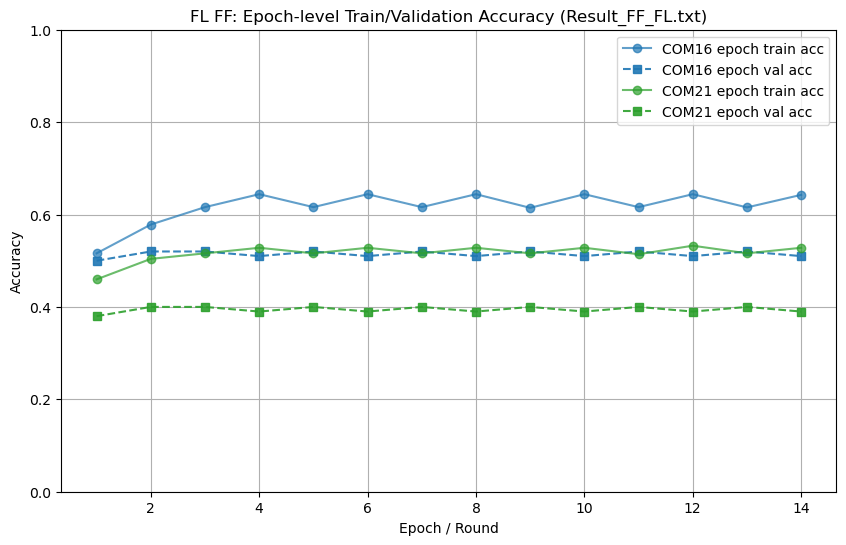

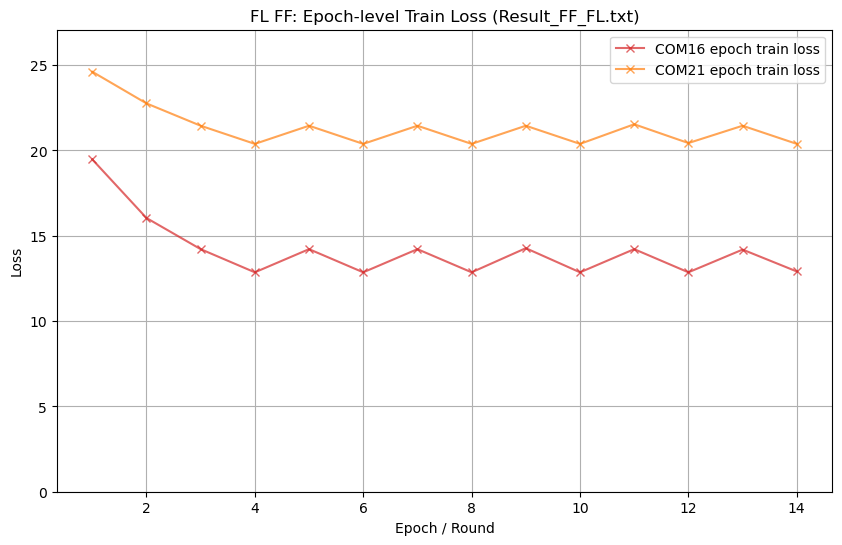

COM16 federated rounds (inferred): 6
COM16 per-round train acc: [np.float64(0.5471566265060241), np.float64(0.63), np.float64(0.63), np.float64(0.63), np.float64(0.6292289156626506), np.float64(0.63)]
COM16 per-round train loss: [np.float64(17.75854686393574), np.float64(13.536108968), np.float64(13.536108968), np.float64(13.536108968), np.float64(13.564652939686747), np.float64(13.536108968)]
COM16 per-round val acc: [0.5, 0.52, 0.52, 0.51, 0.52, 0.51]
COM21 federated rounds (inferred): 6
COM21 per-round train acc: [np.float64(0.4818387096774194), np.float64(0.522), np.float64(0.522), np.float64(0.522), np.float64(0.522), np.float64(0.5232882750514252)]
COM21 per-round train loss: [np.float64(23.684678026564516), np.float64(20.915266674), np.float64(20.915266674), np.float64(20.915266674), np.float64(20.915266674), np.float64(20.982678876530514)]
COM21 per-round val acc: [0.38, 0.4, 0.4, 0.39, 0.4, 0.39]


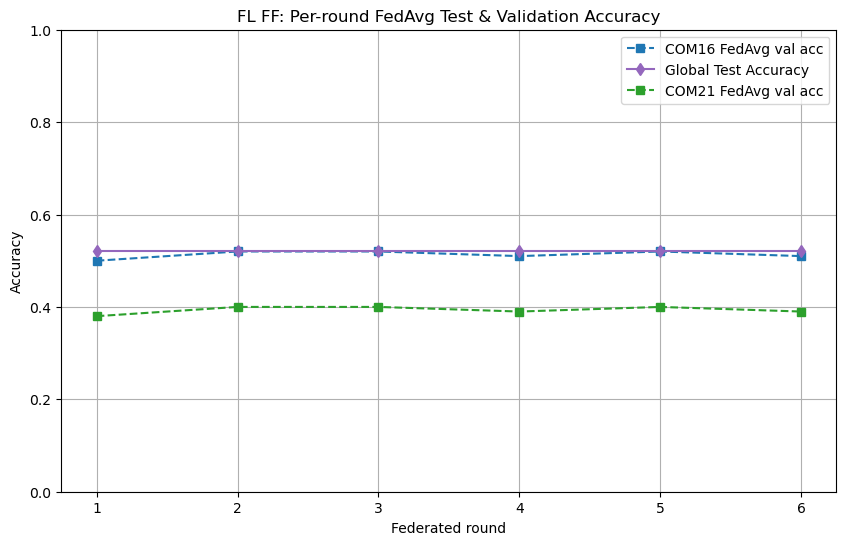

: 

In [ ]:
import re
import numpy as np
import matplotlib.pyplot as plt

with open("Result_FF_FL.txt", "r", encoding="utf-8") as f:
    text = f.read()

lines = text.splitlines()

line_pattern = re.compile(r"^\[(COM16|COM21)\] (.+)$")
train_pattern = re.compile(r"WinAcc\((\d+)\): ([0-9.]+) \| WinAvgLoss\(\d+\): ([0-9.]+)")
val_pattern = re.compile(r"STM32 inference accuracy = ([0-9.]+)")

train_acc_by_round = {"COM16": [], "COM21": []}
train_loss_by_round = {"COM16": [], "COM21": []}
current_train_acc = {"COM16": [], "COM21": []}
current_train_loss = {"COM16": [], "COM21": []}

vals = {"COM16": [], "COM21": []}
train_finish_counts = {"COM16": 0, "COM21": 0}
val_finish_counts = {"COM16": 0, "COM21": 0}
test_finish_counts = {"COM16": 0, "COM21": 0}

for line in lines:
    m = line_pattern.match(line.strip())
    if not m:
        continue
    client, body = m.group(1), m.group(2)

    m_train = train_pattern.search(body)
    if m_train:
        acc = float(m_train.group(2))
        loss = float(m_train.group(3))
        current_train_acc[client].append(acc)
        current_train_loss[client].append(loss)
        continue

    m_val = val_pattern.search(body)
    if m_val:
        vals[client].append(float(m_val.group(1)))
        continue

    if 'Training data finished' in body:
        train_finish_counts[client] += 1
        if current_train_acc[client]:
            train_acc_by_round[client].append(float(np.mean(current_train_acc[client])))
            train_loss_by_round[client].append(float(np.mean(current_train_loss[client])))
            current_train_acc[client] = []
            current_train_loss[client] = []
    elif 'Inference data finished' in body:
        val_finish_counts[client] += 1
    elif 'Test data finished' in body:
        test_finish_counts[client] += 1

print('Train finish counts:', train_finish_counts)
print('Validation finish counts:', val_finish_counts)
print('Test finish counts:', test_finish_counts)

for client in ['COM16', 'COM21']:
    print(f"{client}: {len(train_acc_by_round[client])} epoch averages, {len(vals[client])} val records")

# Plot epoch-level metrics
plt.figure(figsize=(10, 6))
for client, color in [('COM16', 'tab:blue'), ('COM21', 'tab:green')]:
    epoch_acc = train_acc_by_round[client]
    epoch_val = vals[client]
    if epoch_acc:
        plt.plot(range(1, len(epoch_acc)+1), epoch_acc, marker='o', linestyle='-', color=color, alpha=0.7,
                 label=f"{client} epoch train acc")
    if epoch_val:
        plt.plot(range(1, len(epoch_val)+1), epoch_val, marker='s', linestyle='--', color=color, alpha=0.9,
                 label=f"{client} epoch val acc")

plt.xlabel('Epoch / Round')
plt.ylabel('Accuracy')
plt.title('FL FF: Epoch-level Train/Validation Accuracy (Result_FF_FL.txt)')
plt.legend()
plt.grid(True)
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(10, 6))
for client, color in [('COM16', 'tab:red'), ('COM21', 'tab:orange')]:
    epoch_loss = train_loss_by_round[client]
    if epoch_loss:
        plt.plot(range(1, len(epoch_loss)+1), epoch_loss, marker='x', linestyle='-', color=color, alpha=0.7,
                 label=f"{client} epoch train loss")

plt.xlabel('Epoch / Round')
plt.ylabel('Loss')
plt.title('FL FF: Epoch-level Train Loss (Result_FF_FL.txt)')
plt.legend()
plt.grid(True)
max_loss = max((max(train_loss_by_round['COM16']) if train_loss_by_round['COM16'] else 1),
               (max(train_loss_by_round['COM21']) if train_loss_by_round['COM21'] else 1))
plt.ylim(0, max_loss * 1.1)
plt.show()

# ======== Federated round aggregation (inferred from log) ========
round_test_acc = {'COM16': [], 'COM21': []}
round_test_pattern = re.compile(r'^\[(COM16|COM21)\] FedRound (\d+) TestAcc = ([0-9.]+)$')
for line in lines:
    m = round_test_pattern.match(line.strip())
    if m:
        client, rnd, acc = m.groups()
        round_test_acc[client].append((int(rnd), float(acc)))

# infer fed rounds from highest round index found in any client
fed_rounds = 0
for client in ['COM16', 'COM21']:
    if round_test_acc[client]:
        fed_rounds = max(fed_rounds, max(rnd for rnd, _ in round_test_acc[client]))

if fed_rounds == 0:
    fed_rounds = max(1, min(len(vals['COM16']), len(vals['COM21'])))

for client in ['COM16', 'COM21']:
    epochs = len(train_acc_by_round[client])
    if epochs == 0:
        print(f"{client}: no training epochs to aggregate")
        continue

    per_round = max(1, epochs // fed_rounds)

    round_train_acc = [
        np.mean(train_acc_by_round[client][i*per_round:(i+1)*per_round])
        for i in range(fed_rounds)
        if len(train_acc_by_round[client][i*per_round:(i+1)*per_round]) == per_round
    ]
    round_train_loss = [
        np.mean(train_loss_by_round[client][i*per_round:(i+1)*per_round])
        for i in range(fed_rounds)
        if len(train_loss_by_round[client][i*per_round:(i+1)*per_round]) == per_round
    ]
    round_val_acc = vals[client][:fed_rounds]

    print(f"{client} federated rounds (inferred): {fed_rounds}")
    print(f"{client} per-round train acc: {round_train_acc}")
    print(f"{client} per-round train loss: {round_train_loss}")
    print(f"{client} per-round val acc: {round_val_acc}")

# Parse test accuracy per round from log file
round_test_acc = {'COM16': [], 'COM21': []}
round_test_pattern = re.compile(r'^\[(COM16|COM21)\] FedRound (\d+) TestAcc = ([0-9.]+)$')
for line in lines:
    m = round_test_pattern.match(line.strip())
    if m:
        client, rnd, acc = m.groups()
        round_test_acc[client].append((int(rnd), float(acc)))

for client in ['COM16', 'COM21']:
    round_test_acc[client].sort()
    values = [a for _, a in round_test_acc[client]]
    # drop final extra evaluation point (post-FL final test)
    if len(values) > fed_rounds:
        values = values[:fed_rounds]
    #print(f"{client} per-round test acc: {values}")

# Combined plot: Federated round test and validation accuracy
plt.figure(figsize=(10, 6))
for client, val_color in [('COM16','tab:blue'), ('COM21','tab:green')]:
    if client == 'COM21':
        test_values = [a for _, a in round_test_acc[client]]
        if len(test_values) > fed_rounds:
            test_values = test_values[:fed_rounds]
        if test_values:
            plt.plot(range(1, len(test_values)+1), test_values, marker='d', linestyle='-', color='tab:purple',
                     label="Global Test Accuracy")

    round_val_acc = vals[client][:fed_rounds]
    if round_val_acc:
        plt.plot(range(1, len(round_val_acc)+1), round_val_acc, marker='s', linestyle='--', color=val_color,
                 label=f"{client} FedAvg val acc")

plt.xlabel('Federated round')
plt.ylabel('Accuracy')
plt.title('FL FF: Per-round FedAvg Test & Validation Accuracy')
plt.legend()
plt.grid(True)
plt.ylim(0, 1)
plt.show()


